# Задача 1: Лингвистика и синтаксический разбор

## Импорт необходимых библиотек

In [18]:
# Стандартные библиотеки
from collections import Counter
import sqlite3
import re

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import seaborn as sns

# Лингвистические библиотеки
import spacy


## Загрузка данных

In [2]:
def load_texts(file_path):
    """
    Загружает текстовые данные из БД.
    
    Args:
        file_path: путь к БД с новостными статьями
    
    Returns:
        df: DataFrame с одним столбцом текстов статей (он уже очищен)
    """
    with sqlite3.connect(file_path) as conn:
        query = """
        SELECT description as text FROM articles WHERE description IS NOT NULL
        """

        df = pd.read_sql(query, conn)
    return df


In [3]:
df = load_texts('data/lenta.db')
df.head(10)


,text
0,"Microsoftопровергла сведения, что она собирает..."
1,"Астрономы предложили гипотезу, описывающую эво..."
2,Десятилетний мальчик (его имя не называется) п...
3,"Песня группы The Beatles ""Hey Jude"" на данный ..."
4,IPO (первичное размещение акций на бирже) Пром...
5,В Санкт-Петербурге были избиты несколько гражд...
6,Компания Coca-Cola в 12-й раз подряд заняла пе...
7,"Кандидат на пост мэра Москвы, глава аппарата п..."
8,"Ведущий грузинского телеканала ""Маэстро"" Васик..."
9,Премьер-министрВладимир Путиннашел две амфоры ...


## Инициализация инструментов

In [4]:
# Инициализация spacy
nlp = spacy.load("ru_core_news_md")

In [5]:
def clean_text(text):
    """
    Полная очистка текста с обработкой скобок и знаков препинания.
    """
    if not isinstance(text, str):
        return ""

    # 1. Замена спецсимволов переноса на пробелы
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # 2. Разделение стыков Латиница/Кириллица
    text = re.sub(r'([a-zA-Z])([а-яА-Я])', r'\1 \2', text)
    text = re.sub(r'([а-яА-Я])([a-zA-Z])', r'\1 \2', text)

    # 3. Обработка ЗНАКОВ ПРЕПИНАНИЯ
    punctuation = ',.:;!?'

    # 3а. Убираем пробелы ПЕРЕД этими знаками ("слово ,") -> "слово,"
    pattern_before = r'\s+([' + re.escape(punctuation) + r'])'
    text = re.sub(pattern_before, r'\1', text)

    # 3б. Добавляем пробел ПОСЛЕ этих знаков, если там сразу буква ("слово,слово") -> "слово, слово"
    pattern_after = r'([' + re.escape(punctuation) + r'])([А-Яа-яA-Za-z])'
    text = re.sub(pattern_after, r'\1 \2', text)

    # 4. Обработка СКОБОК ()
    # 4а. Открывающая скобка: убираем пробел ВНУТРИ после неё "( слово)" -> "(слово)"
    text = re.sub(r'\(\s+', r'(', text)
    # 4б. Открывающая скобка: добавляем пробел ПЕРЕД ней, если там буква "слово(" -> "слово ("
    text = re.sub(r'([А-Яа-яA-Za-z0-9])\(', r'\1 (', text)

    # 4в. Закрывающая скобка: убираем пробел ВНУТРИ перед ней "(слово )" -> "(слово)"
    text = re.sub(r'\s+\)', r')', text)
    # 4г. Закрывающая скобка: добавляем пробел ПОСЛЕ неё, если там буква ")слово" -> ") слово"
    text = re.sub(r'\)([А-Яа-яA-Za-z0-9])', r') \1', text)

    # 5. все множественные пробелы превращаем в один
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [6]:
# Чисти-чисти
tqdm.pandas()
print('Чистим данные')
df['clean_text'] = df['text'].progress_apply(clean_text)
df['clean_text'].head()

Чистим данные


100%|██████████| 99999/99999 [00:26<00:00, 3823.72it/s]


0    Microsoft опровергла сведения, что она собирае...
1    Астрономы предложили гипотезу, описывающую эво...
2    Десятилетний мальчик (его имя не называется) п...
3    Песня группы The Beatles "Hey Jude" на данный ...
4    IPO (первичное размещение акций на бирже) Пром...
Name: clean_text, dtype: str

## Синтаксический разбор предложений и разбиение на пары подлежащее/сказуемое

In [7]:
def extract_pairs(doc):
    """Генератор, который выдает все пары (подлежащее, сказуемое) в предложении"""

    found_pairs = []
    for sent in doc.sents:
        predicates = []

        for token in sent:
            # Проверка глаголов и вспомогательных глаголов
            if token.pos_ in ['VERB', 'AUX']:
                # Поиска среди найденных сказуемого
                if token.dep_ == "ROOT":
                    predicates.append(token)
                elif token.dep_ == "conj":
                    predicates.append(token)

        # Для каждого сказуемого ищем его подлежащее
        for pred in predicates:
            subject = None
            # Ищем среди детей сказуемого
            for child in pred.children:
                if child.dep_ == "nsubj":
                    subject = child
                    break

            # Если пара найдена, сохраняем леммы в нижнем регистре
            if subject and subject.pos_ in ["NOUN", "PROPN", "PRON"]: # Подлежащее обычно существительное, имя собственное или местоимение
                found_pairs.append((subject.lemma_.lower(), pred.lemma_.lower()))

    return found_pairs

In [8]:
def multithread_spacy_proccesing (df):
    texts = df.fillna('').tolist()

    results = []

    #Основная функция многопоточности
    docs_stream = nlp.pipe(texts, batch_size=50, n_process=9)

    for doc in tqdm(docs_stream, total=len(texts), desc="Обработка"):
        pairs = extract_pairs(doc)
        results.append(pairs)

    return results

In [ ]:
# прогресс-бар для pandas

# Сначала протестируем на 100 строках
print("Чтобы было видно progress-bar")
test_result = multithread_spacy_proccesing(df['clean_text'].head(100))

test_result


In [9]:
print("Чтобы было видно progress-bar")
df['pairs'] = multithread_spacy_proccesing(df['clean_text'])

Чтобы было видно progress-bar


Обработка: 100%|██████████| 99999/99999 [16:57<00:00, 98.24it/s] 


In [10]:
df['pairs'].head()

0    [(microsoft, опровергнуть), (представитель, за...
1    [(астроном, предложить), (учёный, находить), (...
2    [(мальчик, позвонить), (инцидент, произойти), ...
3    [(песня, являться), (композиция, занимать), (п...
4    [(президент, заявить), (приём, начинать), (он,...
Name: pairs, dtype: object

## Зависимости совместных употреблений

In [16]:
all_pairs = [] # Все кортежи подлежащее/сказуемое
for pair_list in df['pairs']:
    all_pairs.extend(pair_list)

counter = Counter(all_pairs)

top_20 = counter.most_common(20)

print("ТОП 20 самых частых пар (Подлежащее, Сказуемое):")
print(f"{'#':<3} | {'Подлежащее':<20} | {'Сказуемое':<20} | {'Частота'}")
print("-" * 60)

for i, ((subj, verb), count) in enumerate(top_20, 1):
    print(f"{i:<3} | {subj:<20} | {verb:<20} | {count}")

ТОП 20 самых частых пар (Подлежащее, Сказуемое):
#   | Подлежащее           | Сказуемое            | Частота
------------------------------------------------------------
1   | человек              | погибнуть            | 2985
2   | речь                 | идти                 | 2697
3   | инцидент             | произойти            | 2643
4   | представитель        | заявить              | 1718
5   | сайт                 | сообщать             | 1428
6   | газета               | писать               | 1238
7   | он                   | заявить              | 1192
8   | суд                  | признать             | 1101
9   | он                   | отметить             | 1096
10  | взрыв                | произойти            | 1034
11  | агентство            | сообщать             | 989
12  | глава                | заявить              | 983
13  | никто                | пострадать           | 958
14  | это                  | произойти            | 952
15  | сумма                | состави

## Визуализация результатов

In [47]:
def vizualization(counter):
    top_n = 20
    top = counter.most_common(top_n) # кортеж и частота

    df_viz = pd.DataFrame(top, columns=['Pair', 'Count'])

    df_viz['Subject'] = df_viz['Pair'].apply(lambda x: x[0])
    df_viz['Verb'] = df_viz['Pair'].apply(lambda x: x[1])
    df_viz['Label'] = df_viz['Subject'] + ' - ' + df_viz['Verb']

    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams['figure.figsize'] = (12, 8)

    plt.figure(figsize=(10, 8))
    # Используем barplot, сортируем по Count автоматически
    sns.barplot(data=df_viz, x='Count', y='Label', palette='YlOrRd')
    plt.title(f'Топ-{top_n} наиболее частых пар (Подлежащее — Сказуемое)', fontsize=16, weight='bold')
    plt.xlabel('Частота встречаемости', fontsize=12)
    plt.ylabel('Грамматическая пара', fontsize=12)
    plt.tight_layout()
    plt.show()

    top_subjects = [p[0][0] for p in counter.most_common(100)]
    top_verbs = [p[0][1] for p in counter.most_common(100)]

    unique_subjects = list(dict.fromkeys(top_subjects))[:15]
    unique_verbs = list(dict.fromkeys(top_verbs))[:15]

    matrix_data = []
    for subj in unique_subjects:
        row = []
        for verb in unique_verbs:
            count = counter.get((subj, verb), 0)
            row.append(count)
        matrix_data.append(row)

    df_matrix = pd.DataFrame(matrix_data, index=unique_subjects, columns=unique_verbs)
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Частота'})
    plt.title('Матрица совместимости: Топ-10 Подлежащих vs Топ-10 Сказуемых', fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

C:\Users\Qweeck\AppData\Local\Temp\ipykernel_18488\3411395639.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_viz, x='Count', y='Label', palette='YlOrRd')


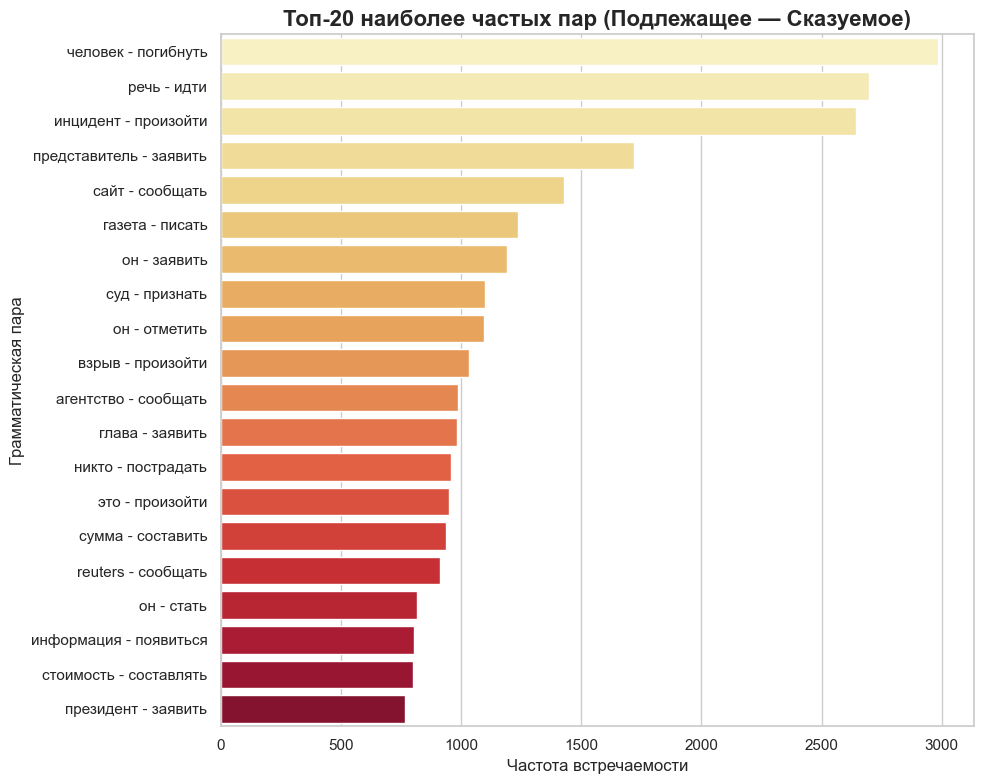

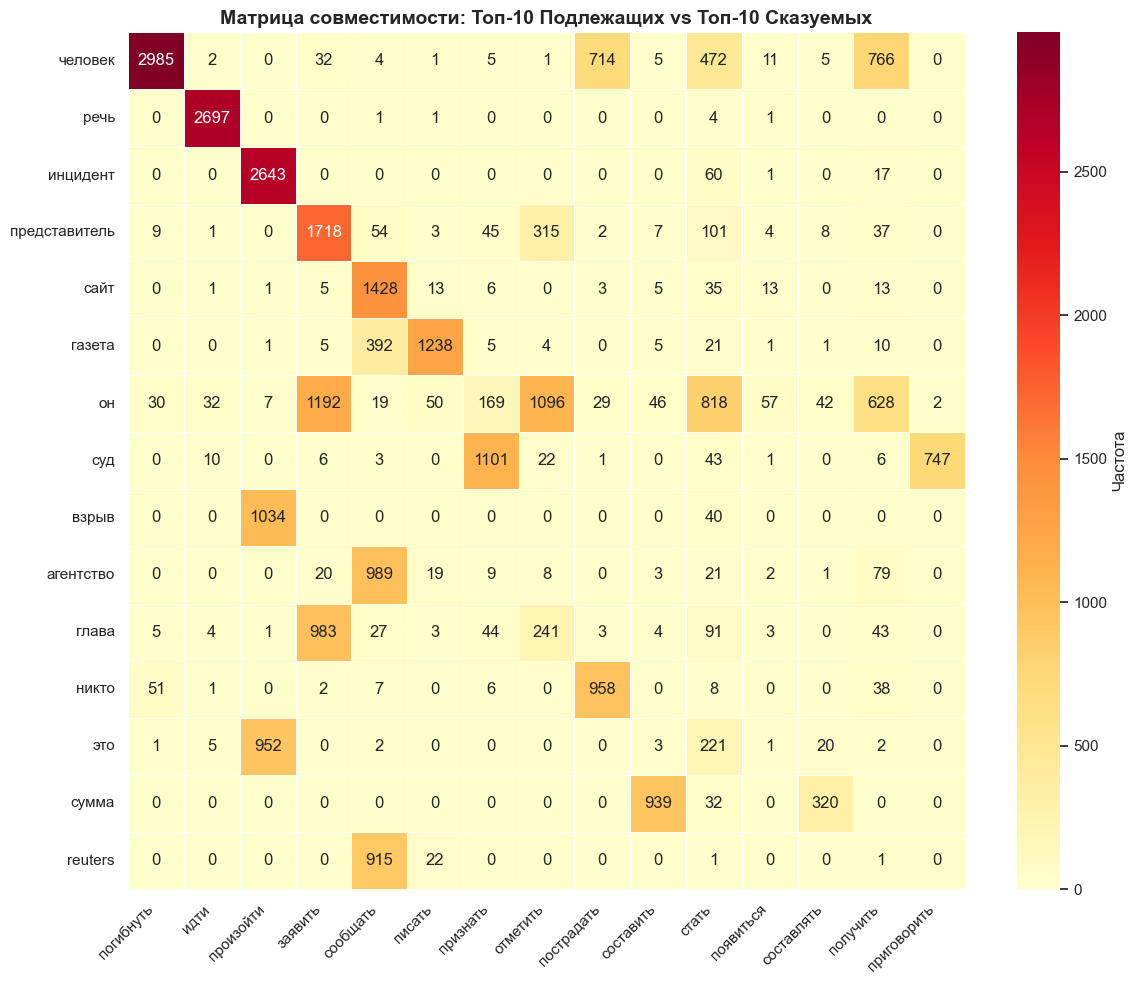

In [48]:
vizualization(counter)